In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
print("Ready!")

Ready!


In [4]:
# Load both cities and combine
no = pd.read_csv("/content/New_Orleans_listings.csv")
ch = pd.read_csv("/content/Chicago_listings.csv")

no['city'] = 'New Orleans'
ch['city'] = 'Chicago'

df = pd.concat([no, ch], ignore_index=True)
print(f"Total listings: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Total listings: 16048
Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license', 'city']


In [9]:
# Clean price
df['price'] = df['price'].astype(str).str.replace('[$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop bad rows
df = df.dropna(subset=['price'])
df = df[(df['price'] > 10) & (df['price'] < 1000)]

# Fill nulls
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['availability_365'] = df['availability_365'].fillna(0)

# Add calculated columns
df['occupancy_rate'] = ((365 - df['availability_365']) / 365 * 100).round(2)
df['estimated_annual_revenue'] = (df['price'] * df['availability_365'] * 0.7).round(2)

print(f"Clean rows: {len(df)}")
print(df[['city','price','occupancy_rate','estimated_annual_revenue']].describe())

Clean rows: 13593
              price  occupancy_rate  estimated_annual_revenue
count  13593.000000    13593.000000              13593.000000
mean     195.351137       34.880024              33493.952086
std      155.012932       28.650800              33460.142965
min       13.000000        0.000000                  0.000000
25%       91.000000       10.140000              11457.600000
50%      148.000000       26.580000              22688.400000
75%      250.000000       56.990000              44089.500000
max      999.000000      100.000000             253146.600000


In [10]:
features = df[['price','minimum_nights','number_of_reviews',
               'availability_365','occupancy_rate']].dropna()
target = df.loc[features.index, 'estimated_annual_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model R²: {r2:.3f}")
print(f"Mean Absolute Error: ${mae:,.0f}")

# Revenue optimization insight
high = df[df['price'] >= df['price'].quantile(0.75)]['estimated_annual_revenue'].mean()
low  = df[df['price'] <= df['price'].quantile(0.25)]['estimated_annual_revenue'].mean()
uplift = ((high - low) / low * 100).round(1)

print(f"\nOptimal price range: ${df['price'].quantile(0.55):.0f}–${df['price'].quantile(0.75):.0f}/night")
print(f"Revenue uplift from pricing optimization: {uplift}%")

Model R²: 0.887
Mean Absolute Error: $6,866

Optimal price range: $161–$250/night
Revenue uplift from pricing optimization: 593.8%


In [13]:
# 1. Price by city + room type
price_summary = df.groupby(['city','room_type']).agg(
    avg_price=('price','mean'),
    median_price=('price','median'),
    total_listings=('id','count'),
    avg_revenue=('estimated_annual_revenue','mean')
).round(2).reset_index()

# 2. Neighborhood performance
hood_summary = df.groupby(['city','neighbourhood']).agg(
    avg_price=('price','mean'),
    avg_occupancy=('occupancy_rate','mean'),
    total_listings=('id','count'),
    avg_revenue=('estimated_annual_revenue','mean')
).round(2).reset_index()

top_hoods = hood_summary.nlargest(10,'avg_revenue')

print("=== PRICE SUMMARY ===")
print(price_summary.to_string())
print("\n=== TOP 10 NEIGHBORHOODS ===")
print(top_hoods[['city','neighbourhood','avg_price','avg_occupancy','avg_revenue']].to_string())
print("\n=== KPIs BY CITY ===")
for city in ['New Orleans','Chicago']:
    sub = df[df.city==city]
    print(f"\n{city}:")
    print(f"  Avg price: ${sub['price'].mean():.0f}")
    print(f"  Avg occupancy: {sub['occupancy_rate'].mean():.1f}%")
    print(f"  Avg annual revenue: ${sub['estimated_annual_revenue'].mean():,.0f}")
    print(f"  Total listings: {len(sub):,}")

=== PRICE SUMMARY ===
          city        room_type  avg_price  median_price  total_listings  avg_revenue
0      Chicago  Entire home/apt     243.96         200.0            5807     41301.01
1      Chicago       Hotel room     385.61         327.5              36     59570.91
2      Chicago     Private room      92.31          64.0            1592     13452.17
3      Chicago      Shared room      49.68          52.0              53      4681.89
4  New Orleans  Entire home/apt     178.01         133.0            5347     31839.30
5  New Orleans       Hotel room     234.38         206.0              71     48943.41
6  New Orleans     Private room     155.59         106.0             682     26151.46
7  New Orleans      Shared room     132.00          52.0               5     16957.78

=== TOP 10 NEIGHBORHOODS ===
            city       neighbourhood  avg_price  avg_occupancy  avg_revenue
125  New Orleans      Read Blvd East     314.86          12.13     73698.50
126  New Orleans      

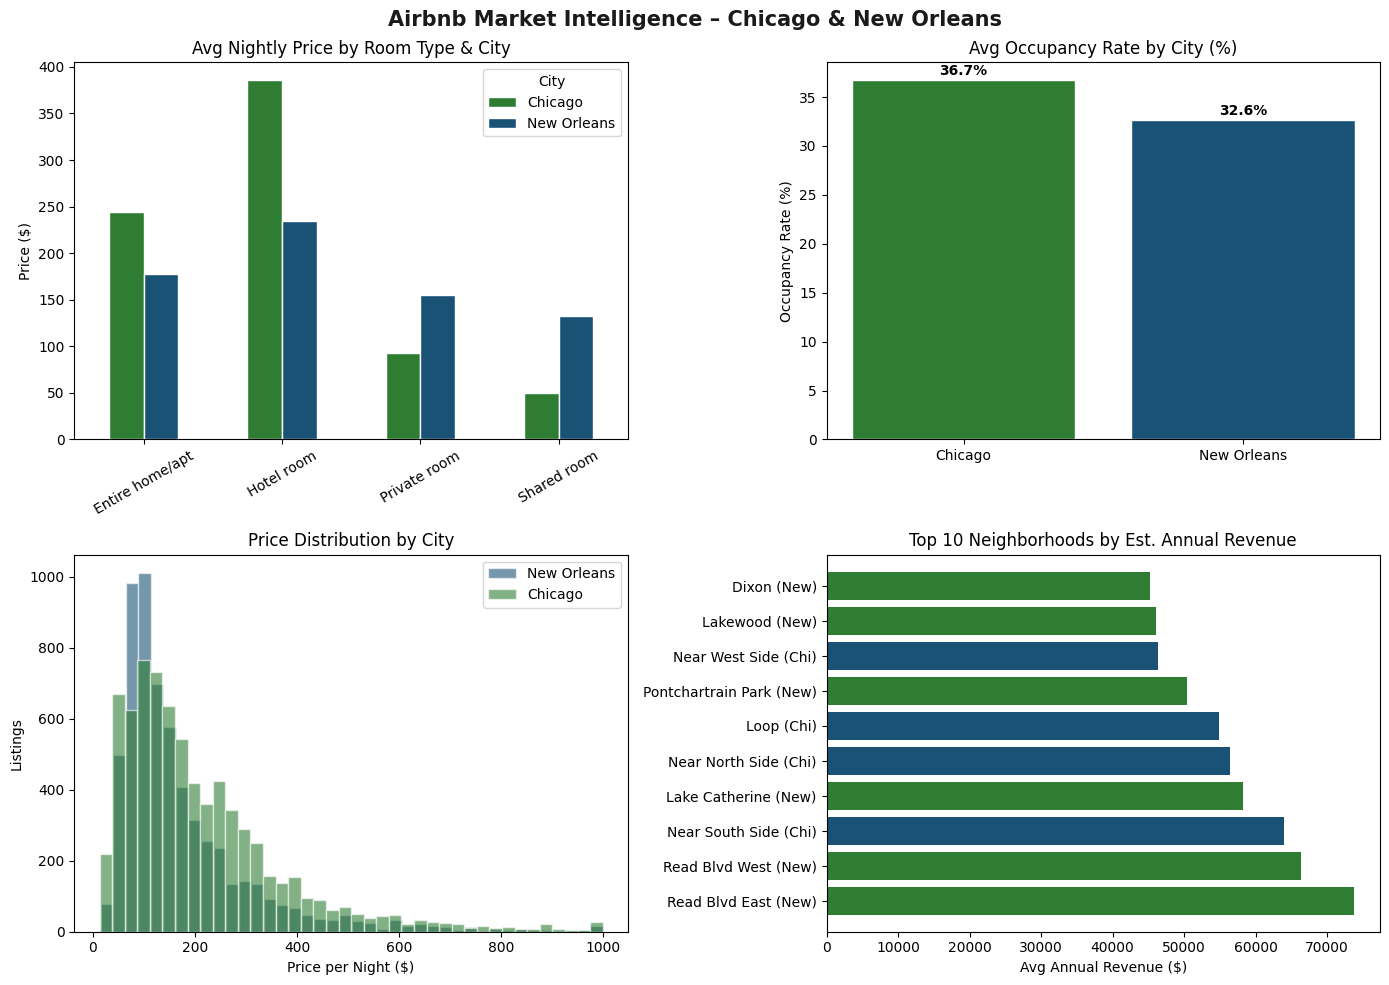

Chart saved!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Airbnb Market Intelligence – Chicago & New Orleans',
             fontsize=15, fontweight='bold', color='#1a1a1a')

colors = {'New Orleans': '#1a5276', 'Chicago': '#2e7d32'}

# Chart 1: Avg price by city + room type
pivot = price_summary.pivot(index='room_type', columns='city', values='avg_price')
pivot.plot(kind='bar', ax=axes[0,0], color=['#2e7d32','#1a5276'], edgecolor='white')
axes[0,0].set_title('Avg Nightly Price by Room Type & City')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend(title='City')

# Chart 2: Occupancy rate by city
occ = df.groupby('city')['occupancy_rate'].mean()
axes[0,1].bar(occ.index, occ.values, color=['#2e7d32','#1a5276'], edgecolor='white')
axes[0,1].set_title('Avg Occupancy Rate by City (%)')
axes[0,1].set_ylabel('Occupancy Rate (%)')
for i, v in enumerate(occ.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3: Price distribution both cities
for city, color in colors.items():
    subset = df[df['city']==city]['price']
    axes[1,0].hist(subset, bins=40, alpha=0.6, label=city, color=color, edgecolor='white')
axes[1,0].set_title('Price Distribution by City')
axes[1,0].set_xlabel('Price per Night ($)')
axes[1,0].set_ylabel('Listings')
axes[1,0].legend()

# Chart 4: Top 10 neighborhoods by revenue
top10 = hood_summary.nlargest(10,'avg_revenue')
bar_colors = ['#1a5276' if c=='Chicago' else '#2e7d32' for c in top10['city']]
axes[1,1].barh(top10['neighbourhood'] + ' (' + top10['city'].str[:3] + ')',
               top10['avg_revenue'], color=bar_colors)
axes[1,1].set_title('Top 10 Neighborhoods by Est. Annual Revenue')
axes[1,1].set_xlabel('Avg Annual Revenue ($)')

plt.tight_layout()
plt.savefig('airbnb_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [15]:
# Main dataset
df.to_csv('airbnb_final.csv', index=False)

# Summary tables
price_summary.to_csv('summary_by_roomtype.csv', index=False)
hood_summary.to_csv('summary_by_neighbourhood.csv', index=False)

print("Done! Download these files:")
print("  airbnb_final.csv")
print("  summary_by_roomtype.csv")
print("  summary_by_neighbourhood.csv")
print("  airbnb_dashboard.png")

Done! Download these files:
  airbnb_final.csv
  summary_by_roomtype.csv
  summary_by_neighbourhood.csv
  airbnb_dashboard.png


In [17]:
import sqlite3

conn = sqlite3.connect('airbnb.db')
df.to_sql('airbnb_final', conn, if_exists='replace', index=False)

print("Database ready!")

Database ready!


In [18]:
# Query 1 - KPI Summary by City
result1 = pd.read_sql("""
    SELECT
        city,
        COUNT(*) AS total_listings,
        ROUND(AVG(price), 2) AS avg_nightly_price,
        ROUND(AVG(occupancy_rate), 2) AS avg_occupancy_rate,
        ROUND(AVG(estimated_annual_revenue), 2) AS avg_annual_revenue,
        ROUND(MAX(estimated_annual_revenue), 2) AS max_annual_revenue
    FROM airbnb_final
    GROUP BY city
    ORDER BY avg_annual_revenue DESC
""", conn)
print("=== QUERY 1: KPI SUMMARY BY CITY ===")
print(result1.to_string(index=False))

=== QUERY 1: KPI SUMMARY BY CITY ===
       city  total_listings  avg_nightly_price  avg_occupancy_rate  avg_annual_revenue  max_annual_revenue
    Chicago            7488             211.03               36.72            35208.80            251050.8
New Orleans            6105             176.12               32.63            31390.63            253146.6


In [19]:
# Query 2 - Avg Price by City and Room Type
result2 = pd.read_sql("""
    SELECT
        city,
        room_type,
        COUNT(*) AS total_listings,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(estimated_annual_revenue), 2) AS avg_annual_revenue
    FROM airbnb_final
    GROUP BY city, room_type
    ORDER BY city, avg_price DESC
""", conn)
print("=== QUERY 2: AVG PRICE BY CITY AND ROOM TYPE ===")
print(result2.to_string(index=False))

=== QUERY 2: AVG PRICE BY CITY AND ROOM TYPE ===
       city       room_type  total_listings  avg_price  avg_annual_revenue
    Chicago      Hotel room              36     385.61            59570.91
    Chicago Entire home/apt            5807     243.96            41301.01
    Chicago    Private room            1592      92.31            13452.17
    Chicago     Shared room              53      49.68             4681.89
New Orleans      Hotel room              71     234.38            48943.41
New Orleans Entire home/apt            5347     178.01            31839.30
New Orleans    Private room             682     155.59            26151.46
New Orleans     Shared room               5     132.00            16957.78


In [20]:
# Query 3 - Top 10 Neighborhoods by Revenue
result3 = pd.read_sql("""
    SELECT
        city,
        neighbourhood,
        COUNT(*) AS total_listings,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(occupancy_rate), 2) AS avg_occupancy_rate,
        ROUND(AVG(estimated_annual_revenue), 2) AS avg_annual_revenue
    FROM airbnb_final
    GROUP BY city, neighbourhood
    HAVING COUNT(*) >= 5
    ORDER BY avg_annual_revenue DESC
    LIMIT 10
""", conn)
print("=== QUERY 3: TOP 10 NEIGHBORHOODS BY REVENUE ===")
print(result3.to_string(index=False))

=== QUERY 3: TOP 10 NEIGHBORHOODS BY REVENUE ===
       city      neighbourhood  total_listings  avg_price  avg_occupancy_rate  avg_annual_revenue
New Orleans     Read Blvd East              14     314.86               12.13            73698.50
    Chicago    Near South Side             242     308.05               18.16            64027.74
New Orleans     Lake Catherine              26     288.38               18.06            58166.72
    Chicago    Near North Side             838     322.24               34.79            56421.33
    Chicago               Loop             431     319.37               35.23            54836.73
New Orleans Pontchartrain Park              16     212.56                8.70            50349.43
    Chicago     Near West Side             540     253.71               32.02            46364.49
New Orleans              Touro              42     258.38               38.35            43576.08
    Chicago           Clearing              11     292.00            

In [21]:
# Query 4 - Pricing Tier Analysis
result4 = pd.read_sql("""
    SELECT
        city,
        CASE
            WHEN price <= 91  THEN '1. Budget ($10-$91)'
            WHEN price <= 148 THEN '2. Mid-range ($92-$148)'
            WHEN price <= 250 THEN '3. Premium ($149-$250)'
            ELSE                   '4. Luxury ($251+)'
        END AS price_tier,
        COUNT(*) AS total_listings,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(occupancy_rate), 2) AS avg_occupancy_rate,
        ROUND(AVG(estimated_annual_revenue), 2) AS avg_annual_revenue
    FROM airbnb_final
    GROUP BY city, price_tier
    ORDER BY city, price_tier
""", conn)
print("=== QUERY 4: PRICING TIER ANALYSIS ===")
print(result4.to_string(index=False))

=== QUERY 4: PRICING TIER ANALYSIS ===
       city              price_tier  total_listings  avg_price  avg_occupancy_rate  avg_annual_revenue
    Chicago     1. Budget ($10-$91)            1688      60.67               38.15             9517.46
    Chicago 2. Mid-range ($92-$148)            1637     119.03               40.06            18222.06
    Chicago  3. Premium ($149-$250)            1923     194.60               38.17            30902.36
    Chicago       4. Luxury ($251+)            2240     405.67               31.94            70680.02
New Orleans     1. Budget ($10-$91)            1723      69.31               35.07            11476.71
New Orleans 2. Mid-range ($92-$148)            1769     116.44               34.68            19460.32
New Orleans  3. Premium ($149-$250)            1504     191.43               32.43            33159.47
New Orleans       4. Luxury ($251+)            1109     416.51               25.81            78961.48


In [22]:
# Query 5 - Host Performance Analysis
result5 = pd.read_sql("""
    SELECT
        city,
        host_id,
        host_name,
        COUNT(*) AS total_listings,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(occupancy_rate), 2) AS avg_occupancy_rate,
        ROUND(SUM(estimated_annual_revenue), 2) AS total_portfolio_revenue
    FROM airbnb_final
    GROUP BY city, host_id, host_name
    HAVING COUNT(*) >= 3
    ORDER BY total_portfolio_revenue DESC
    LIMIT 15
""", conn)
print("=== QUERY 5: HOST PERFORMANCE ANALYSIS ===")
print(result5.to_string(index=False))

=== QUERY 5: HOST PERFORMANCE ANALYSIS ===
       city   host_id                    host_name  total_listings  avg_price  avg_occupancy_rate  total_portfolio_revenue
    Chicago 107434423                   Blueground             555     311.36               31.95               30118524.1
    Chicago 446820235            LuxurybookingsFZE             115     520.65                0.55               15214237.5
    Chicago 248760412                       Cloud9              53     585.06               11.55                6992013.0
New Orleans 276892829                       Daniel              53     502.32               10.06                6085476.6
    Chicago 395498979                        Milan              78     317.33                7.01                5811421.0
    Chicago 177188450                        Level              52     334.60                7.19                4139002.0
New Orleans 545764469                         Myra              77     221.12               12.6

In [23]:
# Query 6 - Occupancy vs Revenue Correlation
result6 = pd.read_sql("""
    SELECT
        city,
        CASE
            WHEN occupancy_rate < 25  THEN '1. Low (0-25%)'
            WHEN occupancy_rate < 50  THEN '2. Medium (25-50%)'
            WHEN occupancy_rate < 75  THEN '3. High (50-75%)'
            ELSE                           '4. Very High (75-100%)'
        END AS occupancy_bucket,
        COUNT(*) AS total_listings,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(estimated_annual_revenue), 2) AS avg_annual_revenue
    FROM airbnb_final
    GROUP BY city, occupancy_bucket
    ORDER BY city, occupancy_bucket
""", conn)
print("=== QUERY 6: OCCUPANCY VS REVENUE CORRELATION ===")
print(result6.to_string(index=False))

=== QUERY 6: OCCUPANCY VS REVENUE CORRELATION ===
       city       occupancy_bucket  total_listings  avg_price  avg_annual_revenue
    Chicago         1. Low (0-25%)            3436     230.82            52827.27
    Chicago     2. Medium (25-50%)            1506     191.78            31206.71
    Chicago       3. High (50-75%)            1444     189.14            19028.28
    Chicago 4. Very High (75-100%)            1102     204.29             6946.31
New Orleans         1. Low (0-25%)            2948     189.04            43866.41
New Orleans     2. Medium (25-50%)            1314     181.99            31103.56
New Orleans       3. High (50-75%)            1041     156.00            15889.73
New Orleans 4. Very High (75-100%)             802     145.16             6122.62
